In [82]:
import numpy as np
import matplotlib.pyplot as plt
import json, os
from games.rps import RPS
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM

from utils.experiment import run_experiment
from utils.io import save_results
from utils.plotting import plot_with_ci, smooth
from utils.metrics import dist_to_ne
from utils.constants import COLORS


In [83]:
N_EPISODES = 20_000
N_SEEDS    = 10
NE_RPS     = np.array([1/3, 1/3, 1/3])
os.makedirs('results/RPS', exist_ok=True)
os.makedirs('figures/RPS', exist_ok=True)

In [84]:
g = RPS()

In [85]:
g.reset()

In [86]:
rm = dict(map(lambda agent: (agent, RegretMatching(game=g, agent=agent, seed=1)), g.agents))

In [87]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, rm[agent].action()), g.agents))
    g.step(actions)

In [88]:
dict(map(lambda agent: (agent, rm[agent].policy()), g.agents))

{'agent_0': array([0.33382656, 0.33902779, 0.32714565]),
 'agent_1': array([0.34451397, 0.31698731, 0.33849871])}

In [89]:
agent_classes = [ RegretMatching, RandomAgent ]
my_agents = {}
g.reset()
for i, agent in enumerate(g.agents):
    my_agents[agent] = agent_classes[i](game=g, agent=agent)


In [90]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, my_agents[agent].action()), g.agents))
    g.step(actions)

In [91]:
dict(map(lambda agent: (agent, my_agents[agent].policy()), g.agents))

{'agent_0': array([0.11428476, 0.80913585, 0.07657939]),
 'agent_1': array([0.33333333, 0.33333333, 0.33333333])}

In [92]:
g.reset()

In [93]:
fp = dict(map(lambda agent: (agent, FictitiousPlay(game=g, agent=agent, seed=1)), g.agents))

In [94]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, fp[agent].action()), g.agents))
    g.step(actions)

In [95]:
dict(map(lambda agent: (agent, fp[agent].policy()), g.agents))

{'agent_0': array([0.33512974, 0.32694611, 0.33792415]),
 'agent_1': array([0.32950115, 0.33929821, 0.33120064])}

In [96]:
agent_classes = [ FictitiousPlay, RandomAgent ]
my_agents = {}
g.reset()
for i, agent in enumerate(g.agents):
    my_agents[agent] = agent_classes[i](game=g, agent=agent)


In [97]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, my_agents[agent].action()), g.agents))
    g.step(actions)

In [98]:
dict(map(lambda agent: (agent, my_agents[agent].policy()), g.agents))

{'agent_0': array([0.17271002, 0.11787034, 0.70941964]),
 'agent_1': array([0.33333333, 0.33333333, 0.33333333])}

In [99]:
g.reset()
iql = dict(map(lambda agent: (agent, IndependentQLearning(game=g, agent=agent, seed=1)), g.agents))

In [100]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, iql[agent].action()), g.agents))
    g.step(actions)

In [101]:
dict(map(lambda agent: (agent, iql[agent].policy()), g.agents))

{'agent_0': array([0.33333333, 0.33333333, 0.33333333]),
 'agent_1': array([0.33333333, 0.33333333, 0.33333333])}

In [102]:
agent_classes = [ IndependentQLearning, RandomAgent ]
my_agents = {}
g.reset()
for i, agent in enumerate(g.agents):
    my_agents[agent] = agent_classes[i](game=g, agent=agent)

In [103]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, my_agents[agent].action()), g.agents))
    g.step(actions)

In [104]:
dict(map(lambda agent: (agent, my_agents[agent].policy()), g.agents))

{'agent_0': array([0.22438304, 0.26792676, 0.5076902 ]),
 'agent_1': array([0.33333333, 0.33333333, 0.33333333])}

#### SECCIÓN 1 — Experimento: FP vs FP


In [105]:
rewards_fp, pol0_fp, pol1_fp = run_experiment(
    RPS, FictitiousPlay, FictitiousPlay, N_EPISODES, N_SEEDS)

save_results('RPS', 'FP_vs_FP', rewards_fp, pol0_fp, pol1_fp,
             ne=NE_RPS.tolist(), hyperparams={'n_episodes': N_EPISODES})

Saved → results/RPS/FP_vs_FP/results.json


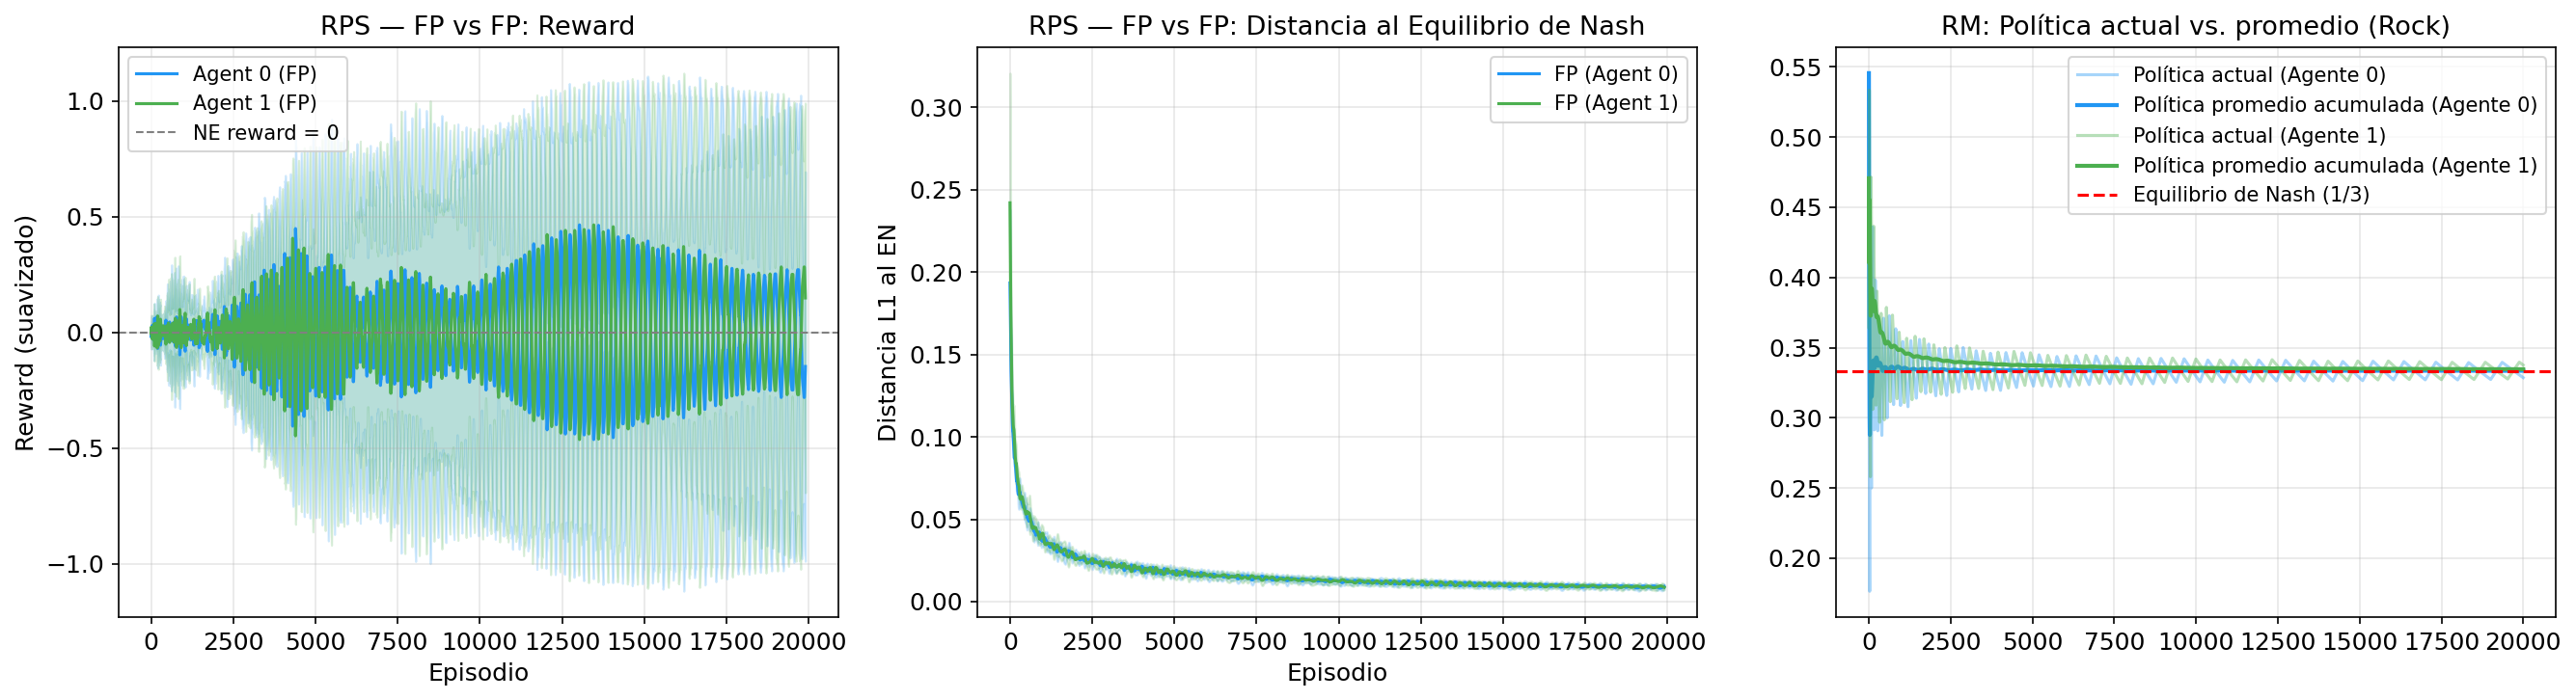

<Figure size 1350x750 with 0 Axes>

Política final FP (promedio sobre seeds):
  Agent 0: [0.331 0.334 0.335]
  Agent 1: [0.335 0.333 0.331]
  Equilibrio de Nash: [0.333 0.333 0.333]


In [106]:
# Gráfica 1a: Reward promedio

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_with_ci(rewards_fp[:, :, 0], 'Agent 0 (FP)', COLORS['FP'], ax=axes[0])
plot_with_ci(rewards_fp[:, :, 1], 'Agent 1 (FP)', COLORS['RM'], ax=axes[0])
axes[0].axhline(0, ls='--', c='gray', lw=1, label='NE reward = 0')
axes[0].set_xlabel('Episodio'); axes[0].set_ylabel('Reward (suavizado)')
axes[0].set_title('RPS — FP vs FP: Reward'); axes[0].legend()

# Gráfica 1b: Distancia al Equilibrio de Nash
d_fp0 = dist_to_ne(pol0_fp, NE_RPS)
d_fp1 = dist_to_ne(pol1_fp, NE_RPS)
plot_with_ci(d_fp0, 'FP (Agent 0)', COLORS['FP'], ax=axes[1])
plot_with_ci(d_fp1, 'FP (Agent 1)', COLORS['RM'], ax=axes[1])
axes[1].set_xlabel('Episodio'); axes[1].set_ylabel('Distancia L1 al EN')
axes[1].set_title('RPS — FP vs FP: Distancia al Equilibrio de Nash'); axes[1].legend()



# Política actual vs. promedio (seed 0, acción Rock)
pol_curr = pol0_fp[0, :, 0]                     # política actual, acción Rock, seed 0
pol_avg  = np.cumsum(pol0_fp[0, :, 0]) / (np.arange(N_EPISODES) + 1)  # promedio acumulado
axes[2].plot(pol_curr, alpha=0.4, color=COLORS['FP'], label='Política actual (Agente 0)')
axes[2].plot(pol_avg,  color=COLORS['FP'], lw=2, label='Política promedio acumulada (Agente 0)')

pol1_curr = pol1_fp[0, :, 0]                     # política actual, acción Rock, seed 0
pol1_avg  = np.cumsum(pol1_fp[0, :, 0]) / (np.arange(N_EPISODES) + 1)  # promedio acumulado
axes[2].plot(pol1_curr, alpha=0.4, color=COLORS['RM'], label='Política actual (Agente 1)')
axes[2].plot(pol1_avg,  color=COLORS['RM'], lw=2, label='Política promedio acumulada (Agente 1)')

axes[2].axhline(1/3, ls='--', c='red', label='Equilibrio de Nash (1/3)')
axes[2].set_title('RM: Política actual vs. promedio (Rock)'); axes[2].legend()
plt.tight_layout(); plt.savefig('figures/RPS/rm_vs_rm.png', dpi=150); plt.show()

plt.tight_layout()
plt.savefig('figures/RPS/fp_vs_fp.png', dpi=150)
plt.show()

# Política final
print("Política final FP (promedio sobre seeds):")
print(f"  Agent 0: {pol0_fp[:, -100:, :].mean(axis=(0,1)).round(3)}")
print(f"  Agent 1: {pol1_fp[:, -100:, :].mean(axis=(0,1)).round(3)}")
print(f"  Equilibrio de Nash: {NE_RPS.round(3)}")


#### SECCIÓN 2 — Experimento: RM vs RM
**Hipótesis:** RM converge al NE (garantía teórica de no-regret). La política PROMEDIO converge; la actual oscila.

Saved → results/RPS/RM_vs_RM/results.json


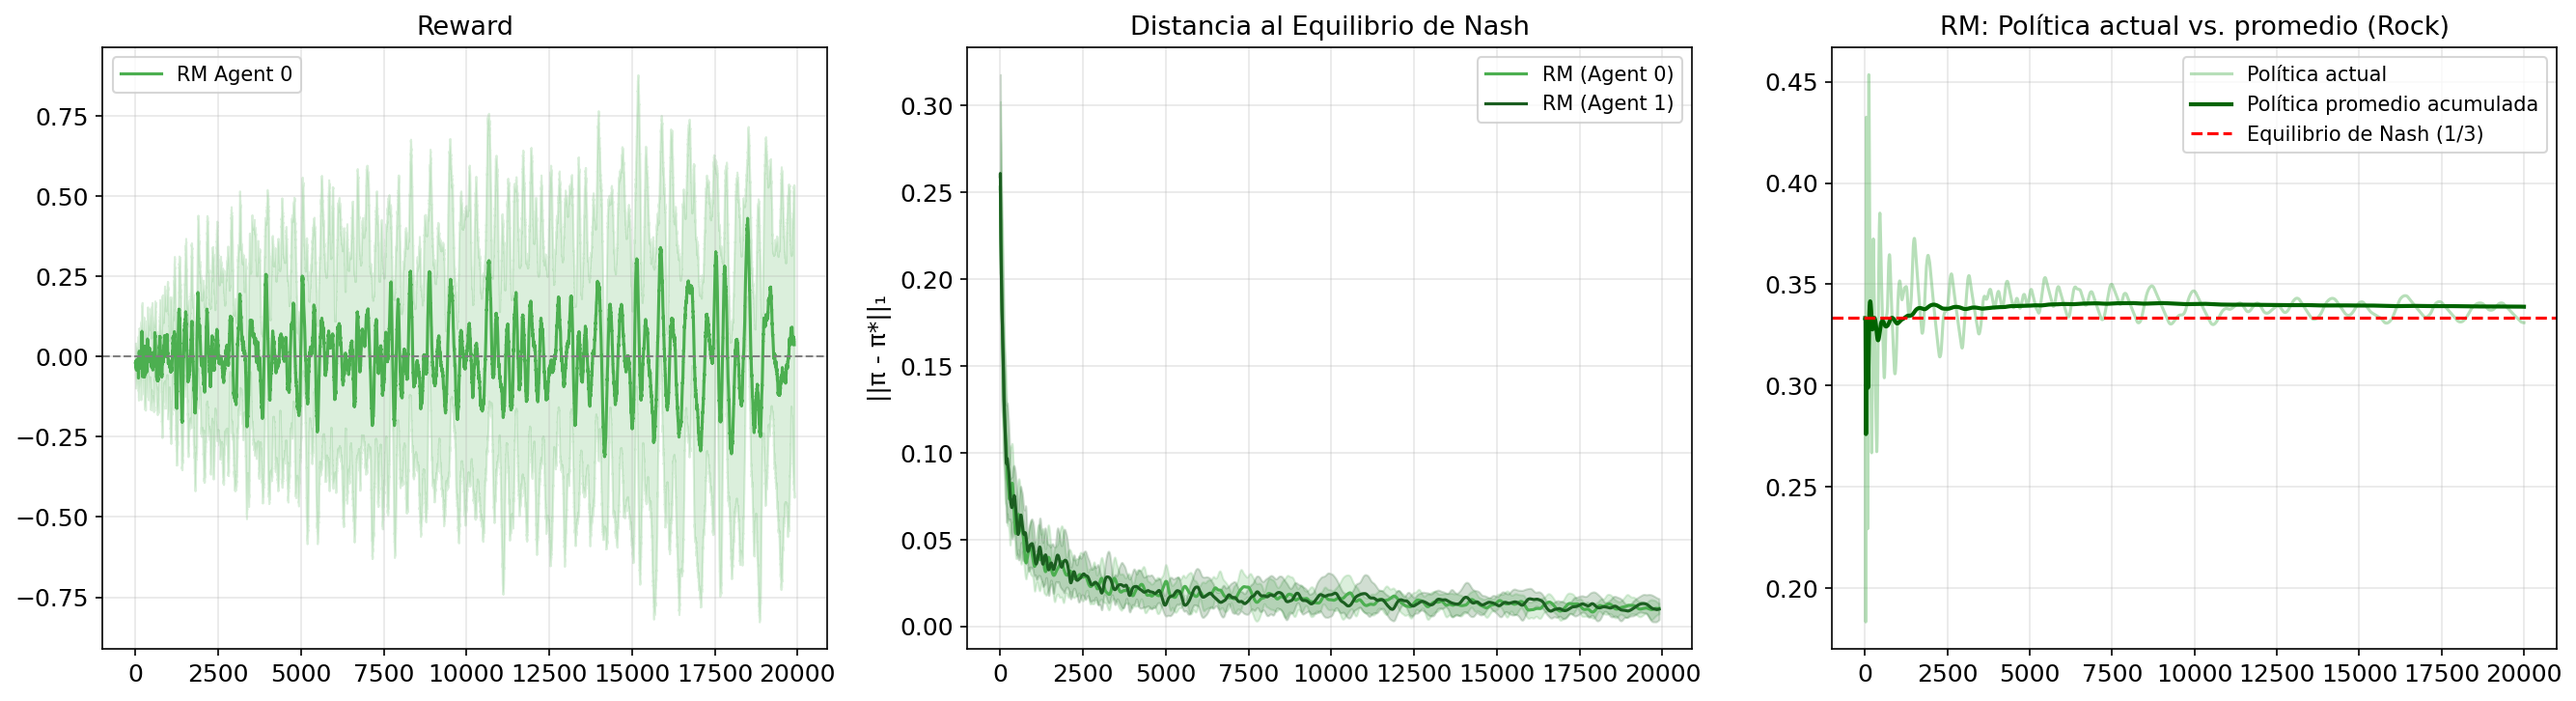

In [107]:
# --- RPS-2: RM vs RM ---
rewards_rm, pol0_rm, pol1_rm = run_experiment(
    RPS, RegretMatching, RegretMatching, N_EPISODES, N_SEEDS)

save_results('RPS', 'RM_vs_RM', rewards_rm, pol0_rm, pol1_rm, ne=NE_RPS.tolist())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reward
plot_with_ci(rewards_rm[:, :, 0], 'RM Agent 0', COLORS['RM'], ax=axes[0])
axes[0].axhline(0, ls='--', c='gray', lw=1); axes[0].set_title('Reward'); axes[0].legend()

# Distancia al Equilibrio de Nash
d_rm0 = dist_to_ne(pol0_rm, NE_RPS)
d_rm1 = dist_to_ne(pol1_rm, NE_RPS)
plot_with_ci(d_rm0, 'RM (Agent 0)', COLORS['RM'], ax=axes[1])
plot_with_ci(d_rm1, 'RM (Agent 1)', '#1B5E20', ax=axes[1])
axes[1].set_title('Distancia al Equilibrio de Nash'); axes[1].set_ylabel('||\u03c0 - \u03c0*||\u2081'); axes[1].legend()

# Política actual vs. promedio (seed 0, acción Rock)
pol_curr = pol0_rm[0, :, 0]                     # política actual, acción Rock, seed 0
pol_avg  = np.cumsum(pol0_rm[0, :, 0]) / (np.arange(N_EPISODES) + 1)  # promedio acumulado
axes[2].plot(pol_curr, alpha=0.4, color=COLORS['RM'], label='Política actual')
axes[2].plot(pol_avg,  color='darkgreen', lw=2, label='Política promedio acumulada')
axes[2].axhline(1/3, ls='--', c='red', label='Equilibrio de Nash (1/3)')
axes[2].set_title('RM: Política actual vs. promedio (Rock)'); axes[2].legend()
plt.tight_layout(); plt.savefig('figures/RPS/rm_vs_rm.png', dpi=150); plt.show()

#### SECCIÓN 3 — Experimento RPS-3: IQL vs IQL
**Hipótesis:** IQL puede ciclar (R→P→S→R) por non-stationarity.


Saved → results/RPS/IQL_vs_IQL/results.json


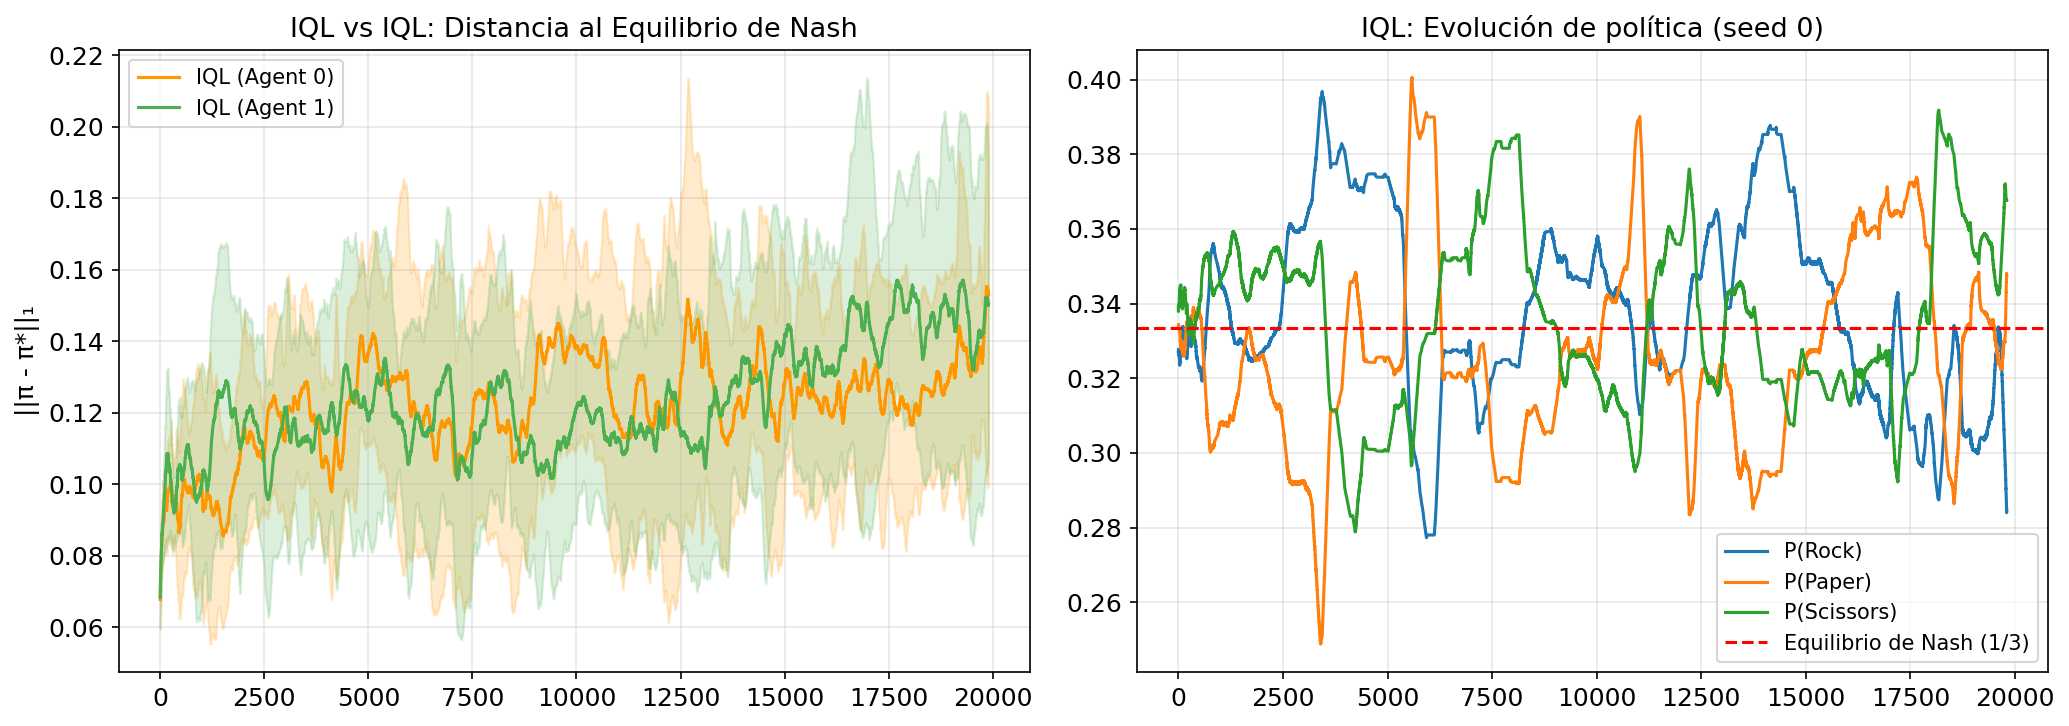

In [108]:
# --- RPS-3: IQL vs IQL ---
iql_kwargs = dict(alpha=0.1, gamma=0.0, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01)
rewards_iql, pol0_iql, pol1_iql = run_experiment(
    RPS, IndependentQLearning, IndependentQLearning, N_EPISODES, N_SEEDS,
    agent0_kwargs=iql_kwargs, agent1_kwargs=iql_kwargs)

save_results('RPS', 'IQL_vs_IQL', rewards_iql, pol0_iql, pol1_iql,
             ne=NE_RPS.tolist(), hyperparams=iql_kwargs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
d_iql0 = dist_to_ne(pol0_iql, NE_RPS)
d_iql1 = dist_to_ne(pol1_iql, NE_RPS)
plot_with_ci(d_iql0, 'IQL (Agent 0)', COLORS['IQL'], ax=axes[0])
plot_with_ci(d_iql1, 'IQL (Agent 1)', COLORS['RM'], ax=axes[0])
axes[0].set_title('IQL vs IQL: Distancia al Equilibrio de Nash'); axes[0].set_ylabel('||\u03c0 - \u03c0*||\u2081'); axes[0].legend()

# Evolución de las 3 acciones (seed 0)
for i, name in enumerate(['Rock', 'Paper', 'Scissors']):
    axes[1].plot(smooth(pol0_iql[0, :, i], 200), label=f'P({name})')
axes[1].axhline(1/3, ls='--', c='red', label='Equilibrio de Nash (1/3)')
axes[1].set_title('IQL: Evolución de política (seed 0)'); axes[1].legend()
plt.tight_layout(); plt.savefig('figures/RPS/iql_vs_iql.png', dpi=150); plt.show()

#### SECCIÓN 4 — Experimento RPS-4: JAL-AM vs JAL-AM


Saved → results/RPS/JALAM_vs_JALAM/results.json


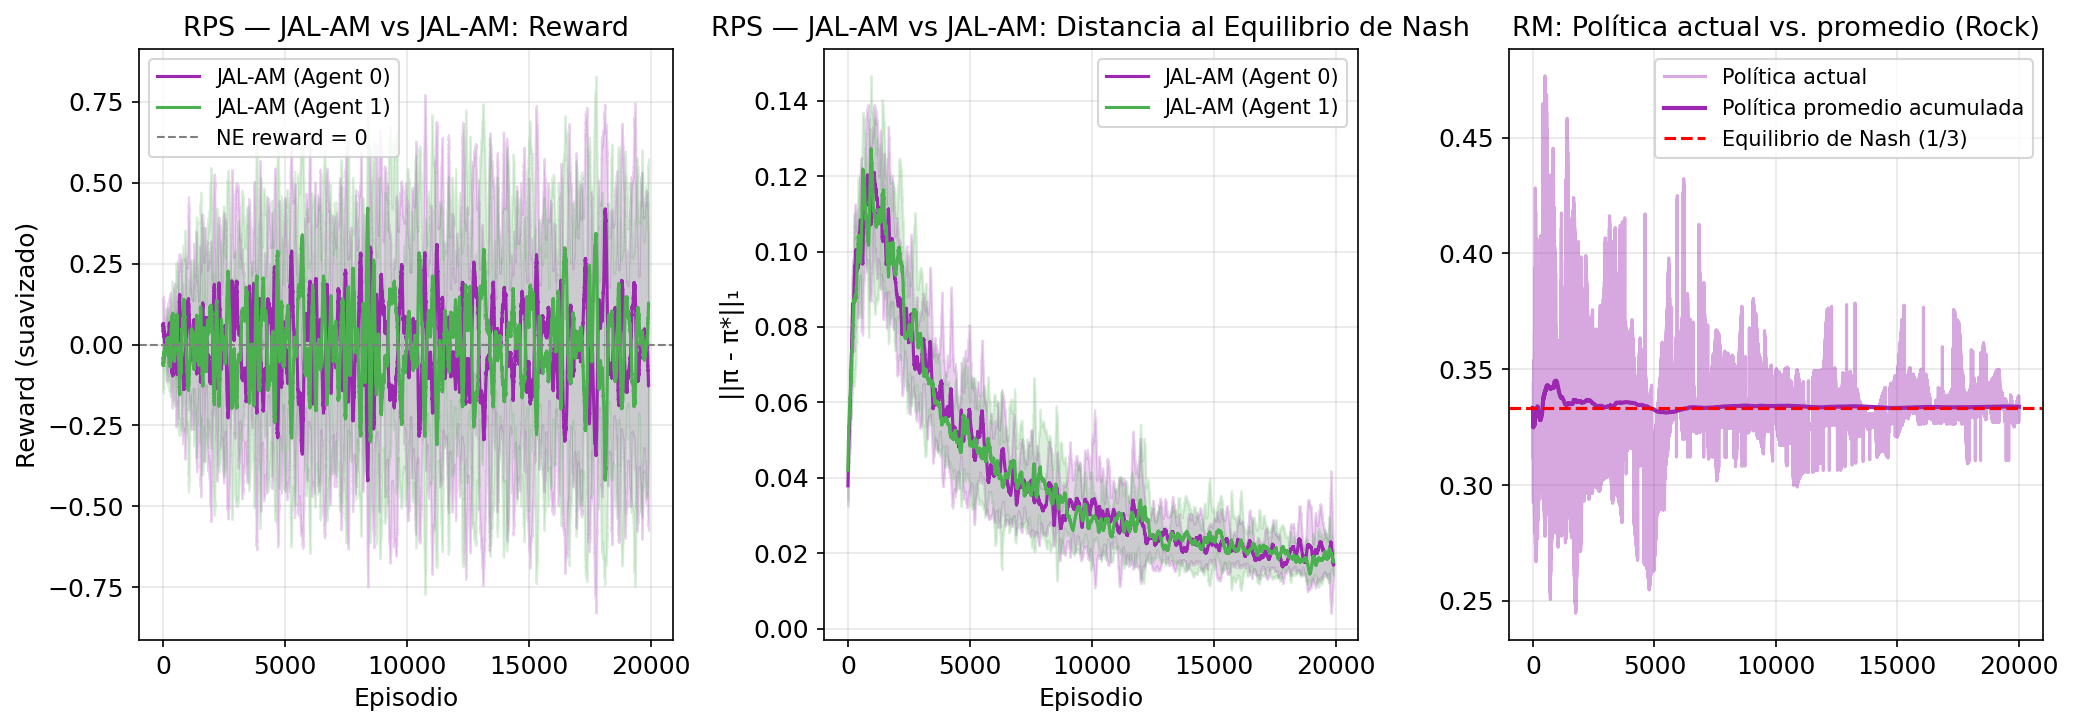

<Figure size 1350x750 with 0 Axes>

In [109]:
# --- RPS-4: JAL-AM vs JAL-AM ---
jalam_kwargs = dict(alpha=0.1, gamma=0.0, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01)
rewards_jal, pol0_jal, pol1_jal = run_experiment(
    RPS, JointActionLearningAM, JointActionLearningAM, N_EPISODES, N_SEEDS,
    agent0_kwargs=jalam_kwargs, agent1_kwargs=jalam_kwargs)

save_results('RPS', 'JALAM_vs_JALAM', rewards_jal, pol0_jal, pol1_jal, ne=NE_RPS.tolist())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Reward
plot_with_ci(rewards_jal[:, :, 0], 'JAL-AM (Agent 0)', COLORS['JAL-AM'], ax=axes[0])
plot_with_ci(rewards_jal[:, :, 1], 'JAL-AM (Agent 1)', COLORS['RM'], ax=axes[0])
axes[0].axhline(0, ls='--', c='gray', lw=1, label='NE reward = 0')
axes[0].set_xlabel('Episodio'); axes[0].set_ylabel('Reward (suavizado)')
axes[0].set_title('RPS — JAL-AM vs JAL-AM: Reward'); axes[0].legend()

# Distancia al Equilibrio de Nash
d_jal0 = dist_to_ne(pol0_jal, NE_RPS)
d_jal1 = dist_to_ne(pol1_jal, NE_RPS)
plot_with_ci(d_jal0, 'JAL-AM (Agent 0)', COLORS['JAL-AM'], ax=axes[1])
plot_with_ci(d_jal1, 'JAL-AM (Agent 1)', COLORS['RM'], ax=axes[1])
axes[1].set_xlabel('Episodio'); axes[1].set_ylabel('||\u03c0 - \u03c0*||\u2081')
axes[1].set_title('RPS — JAL-AM vs JAL-AM: Distancia al Equilibrio de Nash'); axes[1].legend()


# Política actual vs. promedio (seed 0, acción Rock)
pol_curr = pol0_jal[0, :, 0]                     # política actual, acción Rock, seed 0
pol_avg  = np.cumsum(pol0_jal[0, :, 0]) / (np.arange(N_EPISODES) + 1)  # promedio acumulado
axes[2].plot(pol_curr, alpha=0.4, color=COLORS['JAL-AM'], label='Política actual')
axes[2].plot(pol_avg,  color=COLORS['JAL-AM'], lw=2, label='Política promedio acumulada')
axes[2].axhline(1/3, ls='--', c='red', label='Equilibrio de Nash (1/3)')
axes[2].set_title('RM: Política actual vs. promedio (Rock)'); axes[2].legend()
plt.tight_layout(); plt.savefig('figures/RPS/rm_vs_rm.png', dpi=150); plt.show()


plt.tight_layout(); plt.savefig('figures/RPS/jalam_vs_jalam.png', dpi=150); plt.show()

#### SECCIÓN 5 — Experimento RPS-5: Todos vs Random


Saved → results/RPS/FP_vs_Random/results.json
Saved → results/RPS/RM_vs_Random/results.json
Saved → results/RPS/IQL_vs_Random/results.json
Saved → results/RPS/JALAM_vs_Random/results.json


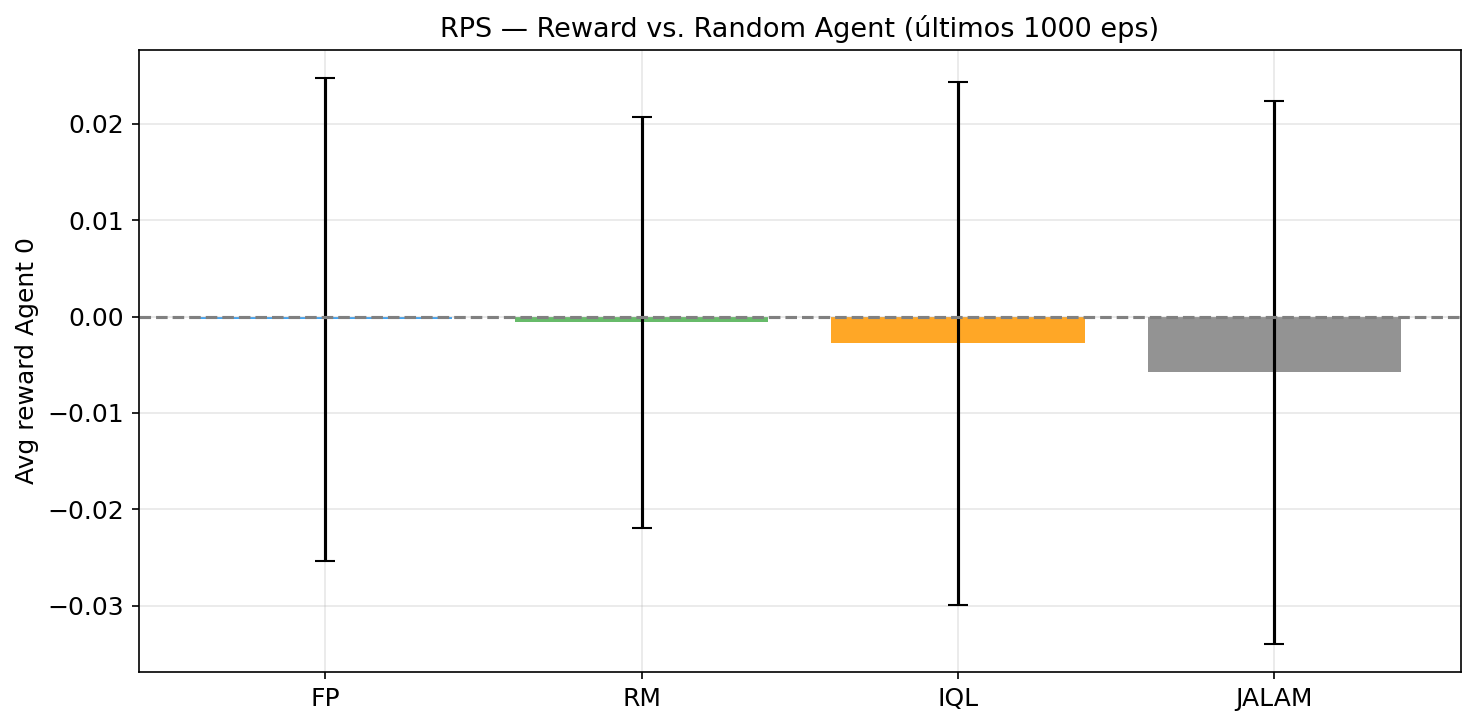

In [110]:
matchups = {
    'FP_vs_Random':    (FictitiousPlay,       RandomAgent,          {}, {}),
    'RM_vs_Random':    (RegretMatching,        RandomAgent,          {}, {}),
    'IQL_vs_Random':   (IndependentQLearning,  RandomAgent, iql_kwargs, {}),
    'JALAM_vs_Random': (JointActionLearningAM, RandomAgent, jalam_kwargs, {}),
}
vs_random_results = {}
for name, (cls0, cls1, kw0, kw1) in matchups.items():
    r, p0, p1 = run_experiment(RPS, cls0, cls1, N_EPISODES, N_SEEDS,
                               agent0_kwargs=kw0, agent1_kwargs=kw1)
    vs_random_results[name] = (r, p0, p1)
    save_results('RPS', name, r, p0, p1)

# Barplot comparativo: avg reward últimos 1000 episodios
fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, (r, _, _)) in enumerate(vs_random_results.items()):
    mean_r = r[:, -1000:, 0].mean()
    std_r  = r[:, -1000:, 0].mean(axis=1).std()
    algo = name.split('_vs_')[0]
    ax.bar(i, mean_r, yerr=std_r, color=COLORS.get(algo, 'gray'),
           capsize=5, label=algo, alpha=0.85)
ax.set_xticks(range(len(matchups))); ax.set_xticklabels([n.split('_vs_')[0] for n in matchups])
ax.set_title('RPS — Reward vs. Random Agent (últimos 1000 eps)'); ax.set_ylabel('Avg reward Agent 0')
ax.axhline(0, ls='--', c='gray'); plt.tight_layout()
plt.savefig('figures/RPS/vs_random_comparison.png', dpi=150); plt.show()

#### SECCIÓN 6 — Experimento RPS-6: Cross-play matrix


In [111]:
# --- RPS-6: Cross-play (todos vs todos) ---
algo_classes = {
    'FP':     (FictitiousPlay,       {}),
    'RM':     (RegretMatching,        {}),
    'IQL':    (IndependentQLearning,  iql_kwargs),
    'JAL-AM': (JointActionLearningAM, jalam_kwargs),
}
algos = list(algo_classes.keys())
win_rate_matrix = np.zeros((len(algos), len(algos)))
draw_rate_matrix = np.zeros((len(algos), len(algos)))

for i, a0_name in enumerate(algos):
    for j, a1_name in enumerate(algos):
        cls0, kw0 = algo_classes[a0_name]
        cls1, kw1 = algo_classes[a1_name]
        r, _, _ = run_experiment(RPS, cls0, cls1, N_EPISODES, N_SEEDS,
                                 agent0_kwargs=kw0, agent1_kwargs=kw1)
        win_rate_matrix[i, j] = (r[:, :, 0] > 0).mean()
        draw_rate_matrix[i, j] = (r[:, :, 0] == 0).mean()


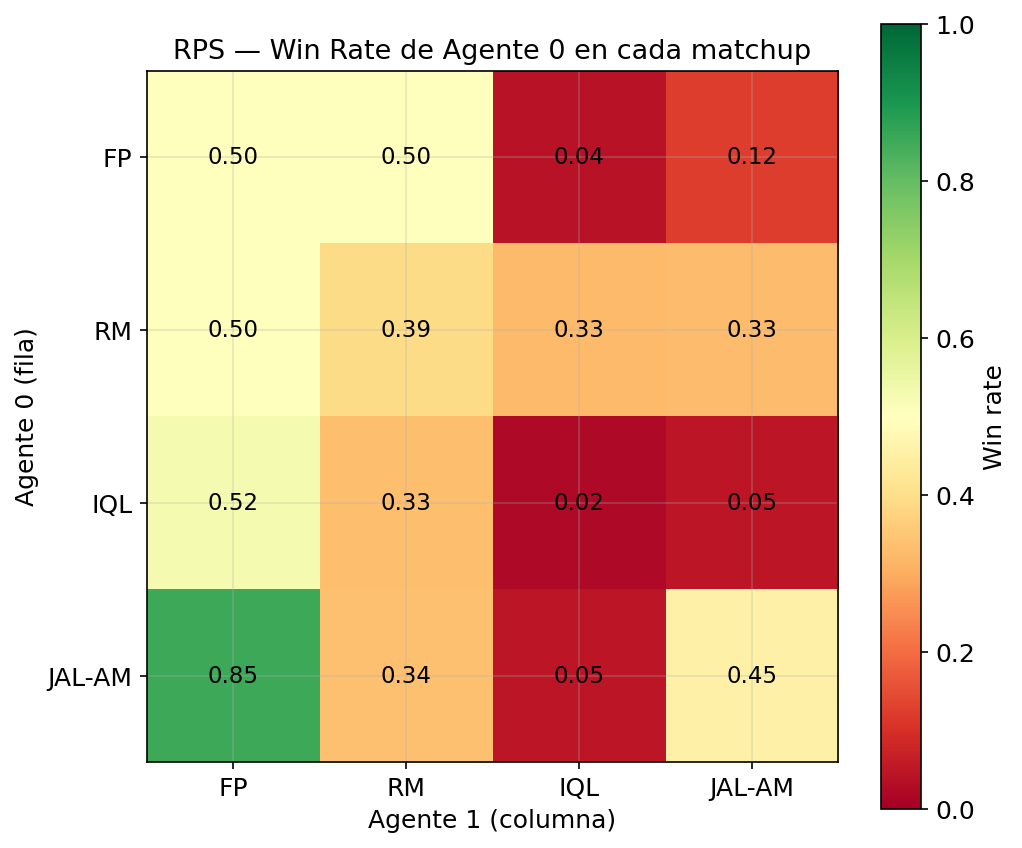

In [112]:
# WIN Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(win_rate_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(algos))); ax.set_yticks(range(len(algos)))
ax.set_xticklabels(algos); ax.set_yticklabels(algos)
ax.set_xlabel('Agente 1 (columna)'); ax.set_ylabel('Agente 0 (fila)')
ax.set_title('RPS — Win Rate de Agente 0 en cada matchup')
plt.colorbar(im, ax=ax, label='Win rate')
for i in range(len(algos)):
    for j in range(len(algos)):
        ax.text(j, i, f'{win_rate_matrix[i,j]:.2f}', ha='center', va='center', fontsize=11)
plt.tight_layout(); plt.savefig('figures/RPS/win_rate_matrix.png', dpi=150); plt.show()

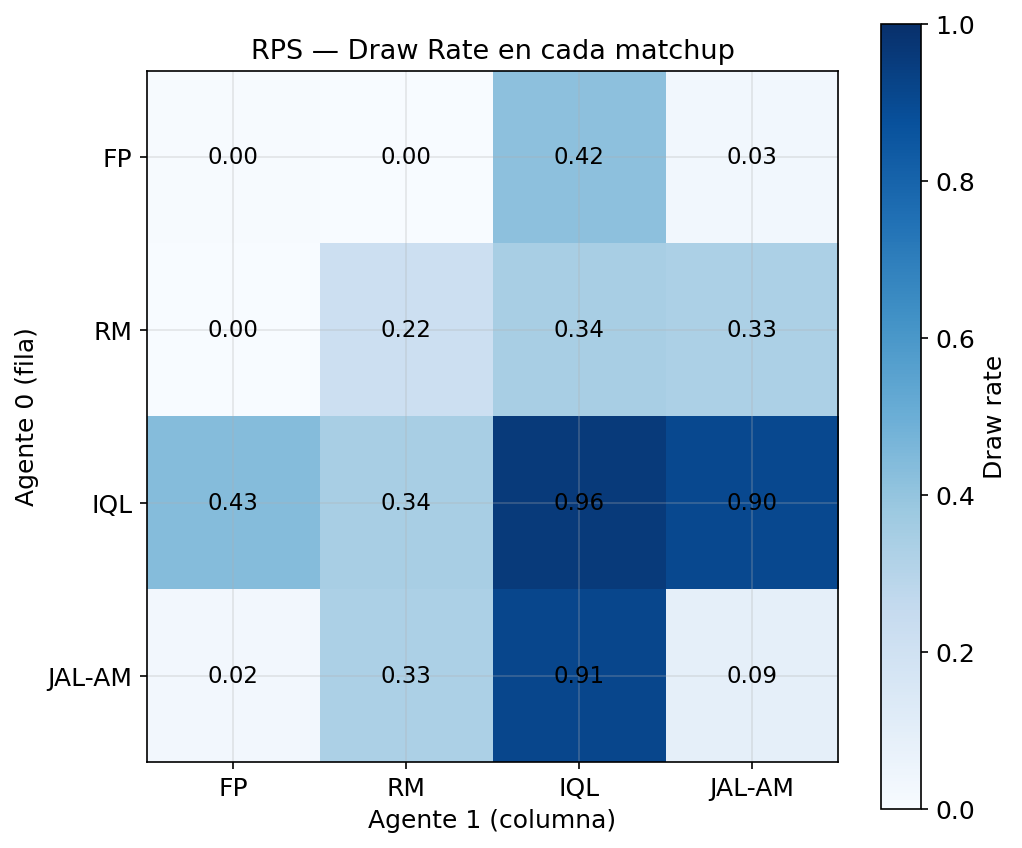

In [113]:
# Heatmap de empates

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(draw_rate_matrix, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(algos)))
ax.set_yticks(range(len(algos)))
ax.set_xticklabels(algos)
ax.set_yticklabels(algos)
ax.set_xlabel('Agente 1 (columna)')
ax.set_ylabel('Agente 0 (fila)')
ax.set_title('RPS — Draw Rate en cada matchup')
plt.colorbar(im, ax=ax, label='Draw rate')
for i in range(len(algos)):
    for j in range(len(algos)):
        ax.text(j, i, f'{draw_rate_matrix[i, j]:.2f}', ha='center', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('figures/RPS/draw_rate_matrix.png', dpi=150)
plt.show()

#### SECCIÓN 7 —  Trajectory Plot en el Simplex (DIFERENCIADOR)


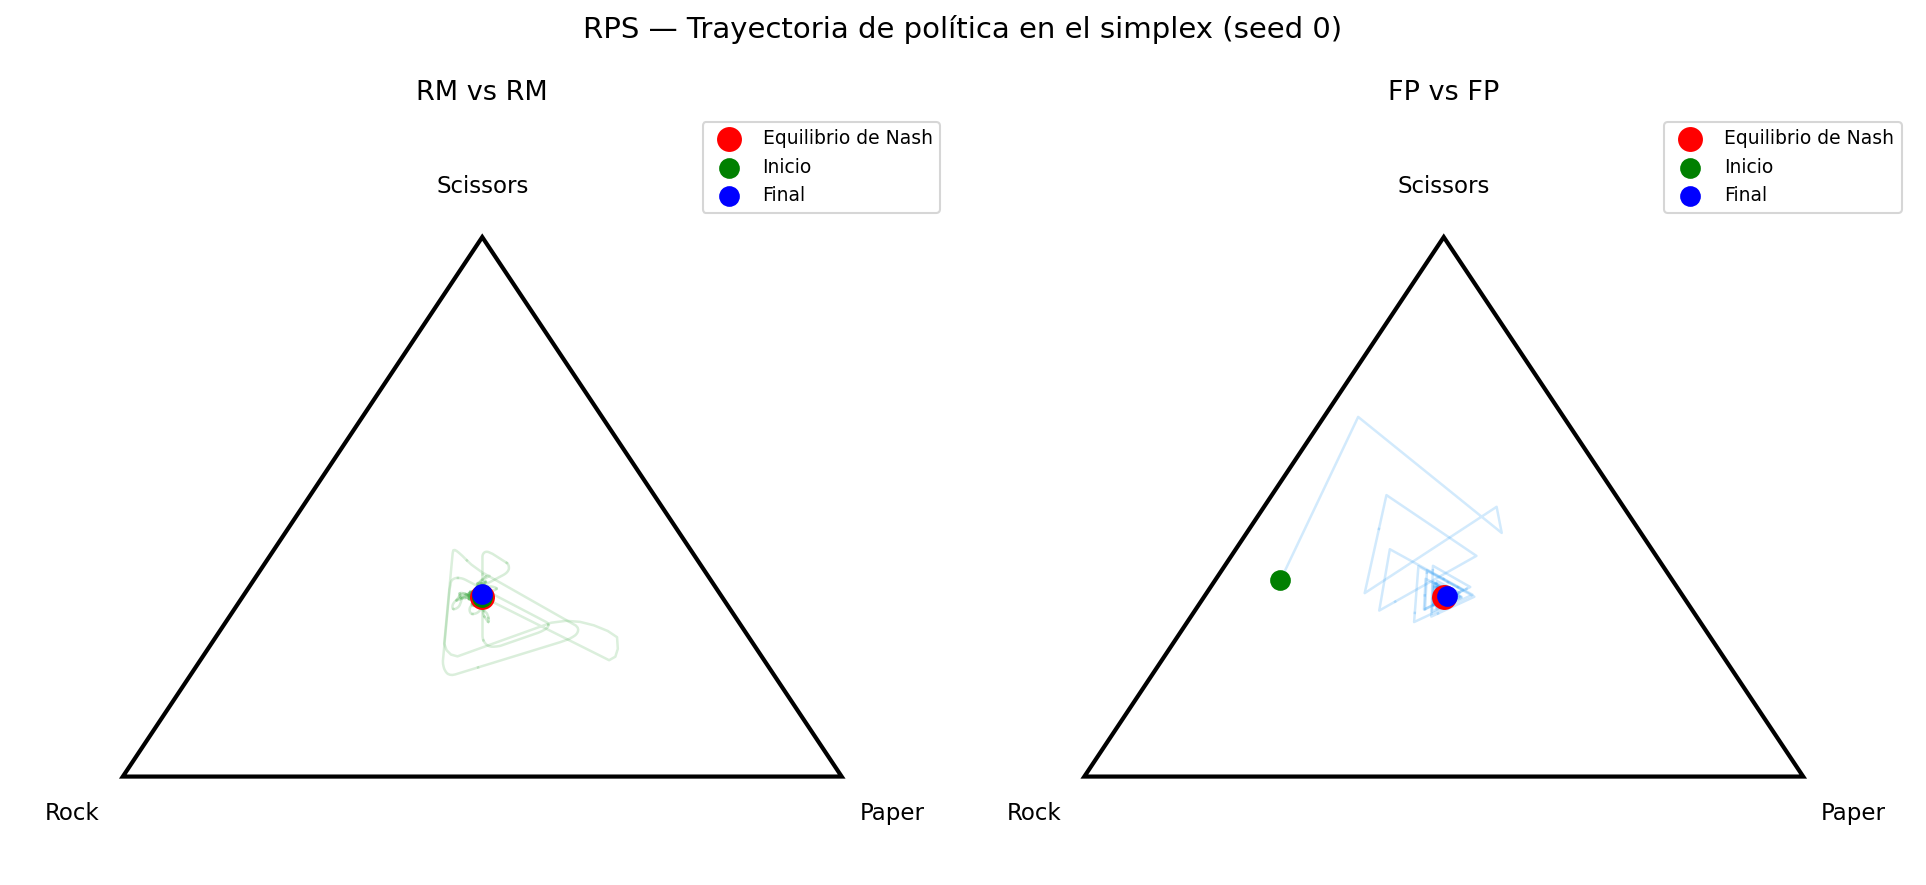

In [114]:
# --- RPS-7: Policy Trajectory en el Simplex ---
def policy_to_simplex(p):
    v = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3)/2]])
    return p @ v

def draw_simplex(ax):
    tri = plt.Polygon([[0,0],[1,0],[0.5,np.sqrt(3)/2]], fill=False, edgecolor='black', lw=2)
    ax.add_patch(tri)
    offset = 0.07
    ax.text(-offset, -offset, 'Rock',     fontsize=11, ha='center')
    ax.text(1+offset, -offset, 'Paper',   fontsize=11, ha='center')
    ax.text(0.5, np.sqrt(3)/2+offset, 'Scissors', fontsize=11, ha='center')
    ne_coord = policy_to_simplex(np.array([1/3,1/3,1/3]))
    ax.scatter(*ne_coord, c='red', s=120, zorder=6, label='Equilibrio de Nash')
    ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.15, np.sqrt(3)/2+0.2)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('RPS — Trayectoria de política en el simplex (seed 0)', fontsize=14)

for ax, pol, name, color in [
    (axes[0], pol0_rm,  'RM',  COLORS['RM']),
    (axes[1], pol0_fp,  'FP',  COLORS['FP']),
]:
    draw_simplex(ax)
    traj = policy_to_simplex(pol[0])  # seed 0, shape (n_episodes, 2)
    # Plotear con gradiente de color para mostrar tiempo
    for k in range(0, len(traj)-1, 50):
        alpha = 0.2 + 0.8 * (k / len(traj))
        ax.plot(traj[k:k+51, 0], traj[k:k+51, 1], color=color, alpha=alpha, lw=1.2)
    ax.scatter(*traj[0],  c='green', s=80, zorder=7, label='Inicio')
    ax.scatter(*traj[-1], c='blue',  s=80, zorder=7, label='Final')
    ax.set_title(f'{name} vs {name}')
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout(); plt.savefig('figures/RPS/simplex_trajectory.png', dpi=150); plt.show()

#### SECCIÓN 8 — Comparación final: todos los algoritmos


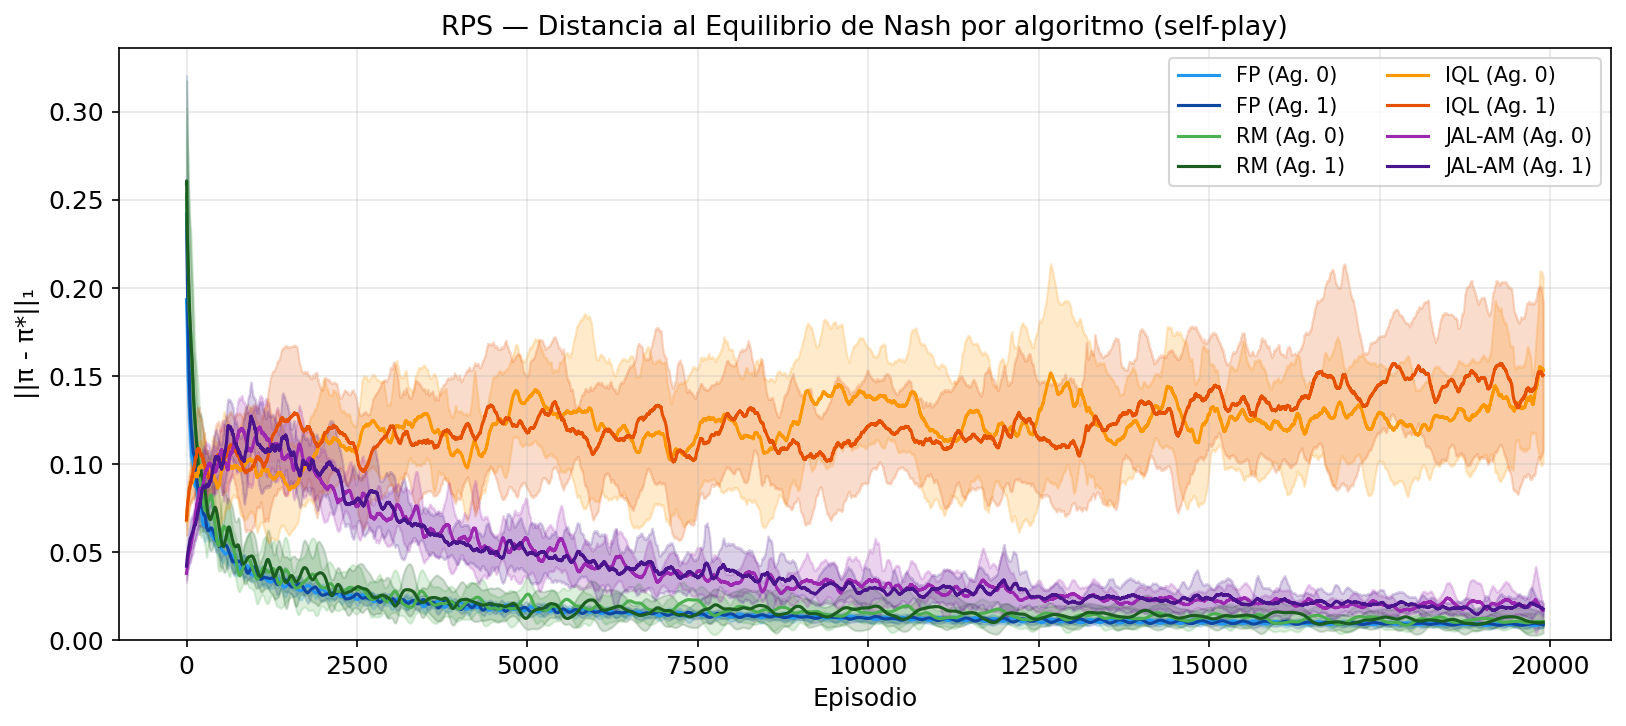


=== TABLA RESUMEN RPS ===
Matchup                       Pol. final A0          Pol. final A1   Dist EN A0   Dist EN A1
-----------------------------------------------------------------------------------------------
FP vs FP                [0.331 0.334 0.335]    [0.335 0.333 0.331]       0.0091       0.0087
RM vs RM                [0.333 0.333 0.334]    [0.333 0.334 0.333]       0.0105       0.0101
IQL vs IQL              [0.328 0.334 0.338]    [0.336 0.328 0.336]       0.1530       0.1505
JAL-AM vs JAL-AM        [0.332 0.336 0.332]    [0.333 0.332 0.335]       0.0169       0.0177


In [115]:
# --- Comparación unificada: distancia al Equilibrio de Nash ---
fig, ax = plt.subplots(figsize=(11, 5))

datasets = [
    (pol0_fp,  pol1_fp,  'FP',     COLORS['FP'],     '#0D47A1'),
    (pol0_rm,  pol1_rm,  'RM',     COLORS['RM'],     '#1B5E20'),
    (pol0_iql, pol1_iql, 'IQL',    COLORS['IQL'],    '#E65100'),
    (pol0_jal, pol1_jal, 'JAL-AM', COLORS['JAL-AM'], '#4A148C'),
]
for pol0, pol1, name, c0, c1 in datasets:
    plot_with_ci(dist_to_ne(pol0, NE_RPS), f'{name} (Ag. 0)', c0, ax=ax)
    plot_with_ci(dist_to_ne(pol1, NE_RPS), f'{name} (Ag. 1)', c1, ax=ax)

ax.set_xlabel('Episodio'); ax.set_ylabel('||\u03c0 - \u03c0*||\u2081')
ax.set_title('RPS — Distancia al Equilibrio de Nash por algoritmo (self-play)')
ax.legend(ncol=2); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.savefig('figures/RPS/all_algos_distance_ne.png', dpi=150); plt.show()

# Tabla resumen
print("\n=== TABLA RESUMEN RPS ===")
print(f"{'Matchup':<20} {'Pol. final A0':>22} {'Pol. final A1':>22} {'Dist EN A0':>12} {'Dist EN A1':>12}")
print("-" * 95)
for pol0, pol1, name, _, _ in datasets:
    pf0 = pol0[:, -100:, :].mean(axis=(0,1))
    pf1 = pol1[:, -100:, :].mean(axis=(0,1))
    d0  = dist_to_ne(pol0, NE_RPS)[:, -100:].mean(axis=1).mean()
    d1  = dist_to_ne(pol1, NE_RPS)[:, -100:].mean(axis=1).mean()
    print(f"{name+' vs '+name:<20} {str(pf0.round(3)):>22} {str(pf1.round(3)):>22} {d0:>12.4f} {d1:>12.4f}")